# Score-sizing denominator · frozen IS mean(|z|) vs rolling mean(|z|)

Other test (not a STAR change). Compares the **sealed backtest / tearsheet** sizing path
(one IS-frozen book-level mean of `|z|`) to the **paper runner** path (per-pair PIT rolling
mean of `|z|`).

| Arm | Denominator | Matches |
|-----|-------------|---------|
| `frozen_is` | `fit_mean_abs_score` on research IS | `01_star_tearsheet` / H-012 sealed backtest |
| `rolling_{w}` | per-pair rolling mean `|z|`, window `w` | `walk_live_book` / paper runner |

STAR stack unchanged. `SIZE_STAR=score` throughout.

**Helpers:** `04_backtest/s2_coint/diagnosis.py`

## 0. Imports & Config

In [1]:
from __future__ import annotations

import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.diagnosis import (
    mean_abs_score_summary,
    plot_rolling_mean_abs,
    run_score_denom_backtest,
)
from backtest.s2_coint.report import load_star_stack, require_star
from backtest.s2_coint.research import (
    DEFAULT_STAR_STACK,
    frozen_pairs_for_universe,
    is_end_for_stack,
    load_s1_weekly,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    split_is_oos,
)
from backtest.s2_coint.tearsheet import fit_mean_abs_score

# Adaptable rolling lookbacks for the sizing denominator (paper runner uses Z_WINDOW_STAR).
ROLLING_WINDOWS: list[int] = [120, 90]

USE_OUT_OF_SAMPLE_DATA = False
STAR_PATH = DEFAULT_STAR_STACK
stack = load_star_stack(STAR_PATH)
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
require_star("SIZE_STAR", stack.get("SIZE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
Z_WINDOW_STAR = int(stack.get("Z_WINDOW_STAR") or 90)

print("UNIVERSE", UNIVERSE)
print("PAIRS", PAIRS)
print("SIZE_STAR", stack.get("SIZE_STAR"))
print("Z_WINDOW_STAR", Z_WINDOW_STAR)
print("ROLLING_WINDOWS", ROLLING_WINDOWS)

UNIVERSE D
PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']
SIZE_STAR score
Z_WINDOW_STAR 90
ROLLING_WINDOWS [120, 90]


## 1. Load panel and overlay STAR hedge / z columns

In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]) if stack.get("OLS_WINDOW_STAR") not in (None, "") else None,
    z_days=int(stack["Z_WINDOW_STAR"]) if stack.get("Z_WINDOW_STAR") not in (None, "") else None,
    adf_days=int(stack["ADF_WINDOW_STAR"]) if stack.get("ADF_WINDOW_STAR") not in (None, "") else None,
)
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
if stack.get("HEDGE_STAR") == "kalman":
    kf_delta = stack["KALMAN_DELTA_STAR"]
    train = overlay_kalman_hedge(
        train,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )
    full = overlay_kalman_hedge(
        full,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )

is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
panel = full
work = panel if USE_OUT_OF_SAMPLE_DATA else is_panel
s1_weekly = load_s1_weekly(ROOT)

frozen_scalar = fit_mean_abs_score(work, date_mask=pd.to_datetime(work["date"]) <= is_end)
print("bar", BAR, "is_end", is_end)
print("work rows", len(work), "pairs", work["pair_id"].nunique())
print("book-level frozen IS mean(|z|)", round(frozen_scalar, 4))
work.head()

bar 1d is_end 2021-12-31 00:00:00
work rows 16177 pairs 3
book-level frozen IS mean(|z|) 0.9357


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1990-01-02,WSO|WSO.B,WSO,WSO.B,1.112374,1.112374,1.112374,1.112374,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Mean |z| summary by pair and window

Per pair: full-sample and IS-only simple means of `|z|`, plus rolling-window stats.
`frozen_is_scalar` is the **pooled** book constant used by the sealed backtest.

In [3]:
summary = mean_abs_score_summary(
    work,
    ROLLING_WINDOWS,
    score_column="z",
    is_end=is_end,
)
display(summary)

pivot = summary.loc[summary["window"] != "frozen_is"].pivot_table(
    index="pair_id",
    columns="window",
    values="rolling_mean_full",
    aggfunc="first",
)
pivot.columns = [f"rolling_mean_full_w{int(c)}" for c in pivot.columns]
pivot["frozen_is_scalar"] = frozen_scalar
pivot["mean_abs_z_is"] = (
    summary.loc[summary["window"] == "frozen_is"]
    .drop_duplicates("pair_id")
    .set_index("pair_id")["mean_abs_z_is"]
)
print("\nPer-pair rolling full-sample mean of rolling mean(|z|) vs frozen IS scalar:")
display(pivot.round(4))

,pair_id,window,mean_abs_z_full,mean_abs_z_is,frozen_is_scalar,rolling_mean_last_is,rolling_mean_full
0,HEI|HEI.A,90,1.067169,1.067169,0.93573,0.834394,1.066297
1,HEI|HEI.A,120,1.067169,1.067169,0.93573,0.819074,1.067377
2,HEI|HEI.A,frozen_is,1.067169,1.067169,0.93573,NaN,NaN
3,NWS|NWSA,90,0.998418,0.998418,0.93573,1.182943,0.999478
4,NWS|NWSA,120,0.998418,0.998418,0.93573,1.170228,0.994882
5,NWS|NWSA,frozen_is,0.998418,0.998418,0.93573,NaN,NaN
6,WSO|WSO.B,90,0.825362,0.825362,0.93573,0.843281,0.825710
7,WSO|WSO.B,120,0.825362,0.825362,0.93573,0.826307,0.824822
8,WSO|WSO.B,frozen_is,0.825362,0.825362,0.93573,NaN,NaN



Per-pair rolling full-sample mean of rolling mean(|z|) vs frozen IS scalar:


,rolling_mean_full_w90,rolling_mean_full_w120,frozen_is_scalar,mean_abs_z_is
pair_id,,,,
HEI|HEI.A,1.0663,1.0674,0.9357,1.0672
NWS|NWSA,0.9995,0.9949,0.9357,0.9984
WSO|WSO.B,0.8257,0.8248,0.9357,0.8254


## 3. Rolling mean |z| time series

Dashed line = pooled IS-frozen scalar (`fit_mean_abs_score`). Solid lines = PIT rolling
mean `|z|` for each window in `ROLLING_WINDOWS`.

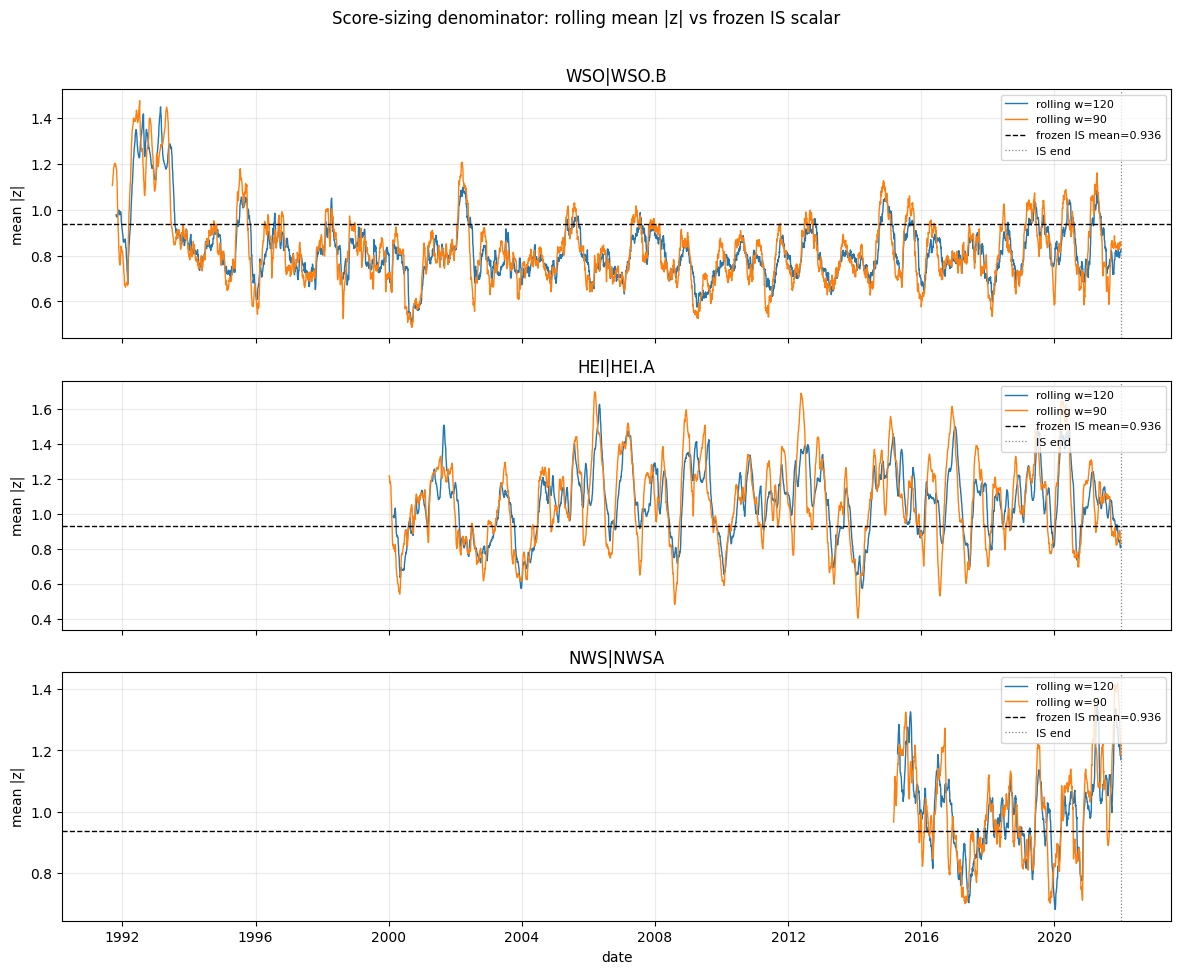

In [4]:
plot_rolling_mean_abs(
    work,
    ROLLING_WINDOWS,
    score_column="z",
    pairs=PAIRS,
    is_end=is_end,
    frozen_is_scalar=frozen_scalar,
)

## 4. Backtest arms · frozen vs rolling denominators

Full frozen STAR stack (`run_s2_backtest`). Research IS only unless
`USE_OUT_OF_SAMPLE_DATA = True`.

In [5]:
arms: dict[str, dict] = {
    "frozen_is": {"denom_mode": "frozen_is", "rolling_window": None},
}
for w in ROLLING_WINDOWS:
    arms[f"rolling_{w}"] = {"denom_mode": "rolling", "rolling_window": int(w)}

rows = []
results = {}
for arm, kw in arms.items():
    res = run_score_denom_backtest(
        panel,
        stack,
        s1_weekly=s1_weekly,
        is_end=is_end,
        use_oos=USE_OUT_OF_SAMPLE_DATA,
        **kw,
    )
    results[arm] = res
    row = {"arm": arm, **res.metrics}
    rows.append(row)
    print(arm, res.metrics)

metrics_df = pd.DataFrame(rows).set_index("arm")
metrics_df

frozen_is {'ann_sharpe': 1.412700846601652, 'max_drawdown': -0.07044114126454781, 'n_days': 8064, 'psr': 1.0, 'dsr_local': nan, 'dsr_stack': nan, 'skew': 1.5304492222024897, 'excess_kurtosis': 17.63061483805295, 'n_trials_local': None, 'n_trials_stack': None, 'corr_to_s1': -0.11716368477660137}
rolling_120 {'ann_sharpe': 1.4381530299731478, 'max_drawdown': -0.06291326352692206, 'n_days': 8064, 'psr': 1.0, 'dsr_local': nan, 'dsr_stack': nan, 'skew': 1.7389166061548968, 'excess_kurtosis': 18.879387922151054, 'n_trials_local': None, 'n_trials_stack': None, 'corr_to_s1': -0.12410458999718356}
rolling_90 {'ann_sharpe': 1.4217936619092457, 'max_drawdown': -0.06257937206529529, 'n_days': 8064, 'psr': 1.0, 'dsr_local': nan, 'dsr_stack': nan, 'skew': 1.7185591687119797, 'excess_kurtosis': 18.39848258832739, 'n_trials_local': None, 'n_trials_stack': None, 'corr_to_s1': -0.122326968576387}


,ann_sharpe,max_drawdown,n_days,psr,dsr_local,dsr_stack,skew,excess_kurtosis,n_trials_local,n_trials_stack,corr_to_s1
arm,,,,,,,,,,,
frozen_is,1.412701,-0.070441,8064,1.0,NaN,NaN,1.530449,17.630615,None,None,-0.117164
rolling_120,1.438153,-0.062913,8064,1.0,NaN,NaN,1.738917,18.879388,None,None,-0.124105
rolling_90,1.421794,-0.062579,8064,1.0,NaN,NaN,1.718559,18.398483,None,None,-0.122327


## 5. Arm comparison (primary metrics)

,ann_sharpe,max_drawdown,corr_to_s1,n_days
arm,,,,
frozen_is,1.4127,-0.0704,-0.1172,8064
rolling_120,1.4382,-0.0629,-0.1241,8064
rolling_90,1.4218,-0.0626,-0.1223,8064


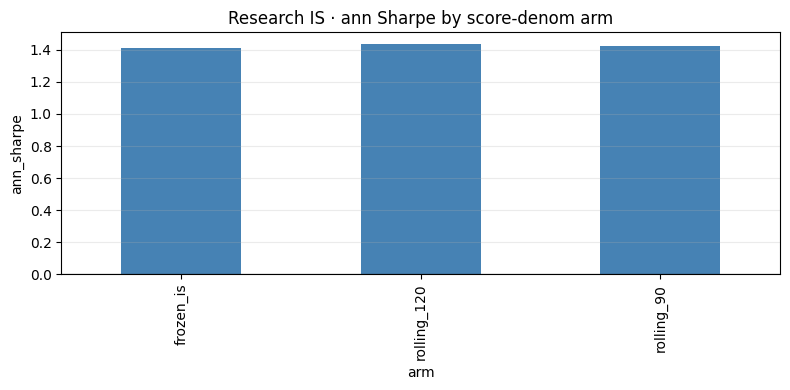

Note: rolling live scale was not walk-forwarded in STAR selection. Set USE_OUT_OF_SAMPLE_DATA=True for sealed OOS once arms are reviewed.


In [6]:
cols = ["ann_sharpe", "max_drawdown", "corr_to_s1", "n_days"]
display(metrics_df[cols].round(4))

fig, ax = plt.subplots(figsize=(8, 4))
metrics_df["ann_sharpe"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Research IS · ann Sharpe by score-denom arm")
ax.set_ylabel("ann_sharpe")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

if not USE_OUT_OF_SAMPLE_DATA:
    print(
        "Note: rolling live scale was not walk-forwarded in STAR selection. "
        "Set USE_OUT_OF_SAMPLE_DATA=True for sealed OOS once arms are reviewed."
    )